# Building a CNN Classifier with PyTorch: Part 1 

In this tutorial, we will walk through the basic components of building a CNN classifier with PyTorch. We will use the [Galaxy10 DECaLS](https://astronn.readthedocs.io/en/latest/galaxy10.html) dataset from [DESI Legacy Imaging Surveys (DECaLS)](https://www.legacysurvey.org/). The data set is specifically focused on morphology of galaxies covered by DECaLS. The images were selected in 10 broad classes. This dataset is used by numerous studies to expolre galaxy morphology classification
<center>
<img src="https://astronn.readthedocs.io/en/latest/_images/galaxy10_example.png" />
</center>


Pytorch is a popular machine learning library for building deep learning models developed by Facebook.  
<img src=images/pytorch_logo.png />

The basics of building a CNN model with Pytorch can be broken down into the following components:

- Dataset Loaders and Transforms
- Building the Neural Network
- Training the Neural Network

Let's get started by importing the modules we need for this notebook as well as set a few hyperparameters needed throughout the notebook. Then, we will dive into the basics of dataset loaders and transforms. 

In [4]:
import torch
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from datetime import datetime
import matplotlib.pyplot as plt
import h5py
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

%matplotlib inline

torch.hub.set_dir('/tmp') # remove when not running here 

This notebook will use the following hyperparameters:

- Learning Rate (lr): how much model parameters are updated at each batch/epoch
- Batch Size: number of data points used to estimate gradients at each iteration
- Epochs: Number of times to iterate over our entire dataset in optimization process

These hyperparameters will be used throughout the notebook and are defined below. 

In [5]:
hp = {"lr":1e-4, "batch_size":16, "epochs":5}

## Dataset Loaders and Transforms

Loading, transforming and preparing data for building deep learning can be messy and difficult to maintain.  Pytorch provides tools to ease this effort and decouples it from the training portion of your machine learning pipeline. Below summarizes the three Pytorch tools we will highlight in this demo: 

- Dataset: stores data and their corresponding labels
- Transforms: performs data manipulation to make data suitable for training
- DataLoaders: iterable around the dataset for ease of access to samples from the dataset.

Let's dive into each of these components and load our design safe dataset.

### Downloading dataset
We first need to get our data set 

In [6]:
! mkdir -p /tmp/data
! cp -r /scratch1/10386/lsmith9003/share/tutorialData/galaxy10/Galaxy10_DECals.h5 /tmp/data/.

# Load images and labels from the Galaxy 10 file 
# (note that we are downsampling slightly to make the dataset more manageable for demonstration)
# TODO: update later
with h5py.File('/tmp/data/Galaxy10_DECals.h5','r') as File:
    labels = np.array(File['ans'])
    indSub = np.where((labels==2) | (labels==5) | (labels==8))
    images = np.array(File['images'])[indSub]
    labels = labels[indSub]
    d = {2:0, 5:1, 8:2}
    mp = np.arange(0,9)
    mp[[int(k) for k in d.keys()]] = [[int(v) for v in d.values()]]
    labels = mp[labels]
    
# Display the shape of our data matrix
print(np.shape(images))

(6111, 256, 256, 3)


### Dataset and Transforms

Next, we set up a function to load our data and subsequently perform needed transforms.  This functions uses a few tools that exist within torchvision.  

#### Dataset

`torch.utils.data.Dataset` is an abstract class in PyTorch that represents a dataset. By subclassing Dataset, you can create custom datasets tailored to your specific needs. This class requires you to implement two essential methods:

\_\_len__: Returns the size of the dataset.

\_\_getitem__: Retrieves a sample from the dataset given an index.

#### Transforms

`torchvision.transforms.Compose` applies a series of transformations to your data. In our function, we use Compose to perform a series of two transforms:

- `torchvision.transforms.Resize` which resizes your image to the specified dimension
- `torchvision.transofrms.ToTensor` converts you images from PIL or numpy arrrays to a torch tensor. 

In the function below, we use `Dataset` to load our train and validation data and perform the needed transformations as described above.

In [7]:
class MyDataset(Dataset):
    def __init__(self, data, targets, transform=None):
        self.data = data
        self.targets = targets
        self.transform = transform
        
    def __getitem__(self, index):
        x = self.data[index]
        y = self.targets[index]
        
        if self.transform:
            x = Image.fromarray(self.data[index].astype(np.uint8))
            x = self.transform(x)        
        return x, y
    
    def __len__(self):
        return len(self.data)

data_train, data_valid, y_train, y_valid = train_test_split(images, labels, test_size=0.2, random_state=42)

# Set up the transformations for data
transform = transforms.Compose([transforms.Resize((224,224)),transforms.ToTensor()])
train_dataset = MyDataset(data_train, y_train, transform=transform)
val_dataset = MyDataset(data_valid, y_valid, transform=transform)
print(f"Train set size: {len(train_dataset)}, Validation set size: {len(val_dataset)}")

Train set size: 4888, Validation set size: 1223


### Construct Dataloaders 

Pytorch's Dataset features load data one by one. When training deep learning models, we typically use a batch gradient descent algorithm to optimize our network and thus we will need to load random images in our specified batch sizes at each gradient descent step. Pytorch's DataLoader is an iterable that automatically performs and loads the data need at each iteration via a simple API.  In the function, we instantiate the DataLoader for our train and validation datasets.  

In [8]:
train_dataloader = DataLoader(train_dataset, batch_size=hp["batch_size"], shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=hp["batch_size"])

### Visualizing the Galaxy10 Dataset

Before we move on to building the architecture of our CNN model, let's visualize some of our Galaxy10 dataset.  

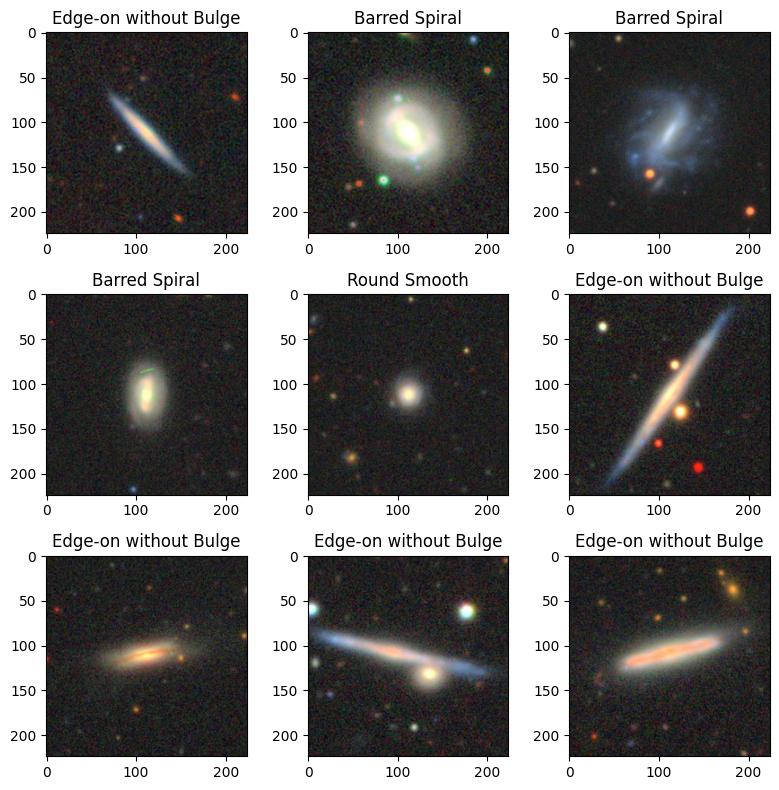

In [9]:
fig,axs = plt.subplots(3,3,figsize=(8, 8))
label_map={0: 'Round Smooth', 1:'Barred Spiral', 2:'Edge-on without Bulge'}
for ax in axs.ravel():
    sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
    img, label = train_dataset[sample_idx]
    ax.imshow(img.permute(1, 2, 0)) #.reshape((224,224,3)))
    ax.set_title(label_map[label])
fig.tight_layout()

As we can see above, our dataset contains images of galaxies. Each of these images has been labeled as Round Smooth, Barred Spiral or Edge-on without Bulge.

## Building the Neural Network

Next, we need to build the architecture of our CNN classfier.  In this tutorial, we will utilize transfer learning.  It is rare for people to build CNN from scratch as we can leverage a CNN model that was trained with very large datasets and apply that knowledge to our use case as is done in transfer learning.  

### ResNet
In this tutorial we will start with the resnet18 model trained with the ImageNet dataset.  Below we instantiate this model and load the pretrained weights. 

In [10]:
resnet = models.resnet18(weights="IMAGENET1K_V1")    

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /tmp/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 109MB/s] 


### Transfer Learning

With transfer learning there are two common ways we can utilize previously optimized weights for specific CNN architectures:

- Start the optimization process of model at the previously optimized weight instead of random weights.  This will accelerate the training process of the entire network.
- Use the previously optimized weights as a fixed feature extractor.  That is, we freeze the previously learned weights except that of the last fully connected layers.  

In this tutorial, we will use ResNet18 as a fixed feature extractor.  Let's start by freezing all the weights in our network:

In [11]:
for param in resnet.parameters():
    param.requires_grad = False 

Note, if we wanted to fine tune our entire model, we could skip the above step. 

Then, we can add a new final fully connected layer.  These parameters will, by default in Pytorch, not be frozen when we replace the final fully connected layers and will be learned in the training process. 

In [12]:
# print last fully connected layer
resnet.fc

Linear(in_features=512, out_features=1000, bias=True)

In [13]:
# get the input dimension for this layer
num_ftrs = resnet.fc.in_features

# build the new final fully connected layers of network
fc = nn.Sequential(
      nn.Linear(num_ftrs, num_ftrs),
      nn.ReLU(),
      nn.Linear(num_ftrs, 3)
    )

# replace final fully connected layer
resnet.fc = fc

## Training the Neural Network

### Define Loss Function and Optimizer

Now that we have our dataloaders set up and our model architecture built, we are ready to train our model.  To train the model, we need to set up a loss function and an optimizer to optimize that loss function.  Below we instantiate the Cross Entropy Loss function and the Adam optimizer. 


In [14]:
opt = torch.optim.Adam(resnet.parameters(),lr=hp["lr"])
loss_fn = nn.CrossEntropyLoss()

Note that we are using the learning rate hyperparameter specified at the the top of this notebook.

In [15]:
hp

{'lr': 0.0001, 'batch_size': 16, 'epochs': 5}

### Train and Model Evaluation Functions

Finally, we need to define standard pytorch train and evaluation functions.  The function `train` iterates over multiple epochs and all batches of data in each epoch.  Model parameters are updated for each batch with the given loss function and optimizer.  The model accuracy and loss is computing with testing data at every epoch.

In [16]:
@torch.no_grad()
def eval_model(data_loader, model, loss_fn, DEVICE):
  model.eval()
  loss, accuracy = 0.0, 0.0
  n = len(data_loader)

  for i, data in enumerate(data_loader):
    x,y = data
    x,y = x.to(DEVICE), y.to(DEVICE)
    pred = model(x)
    loss += loss_fn(pred, y)/len(x)
    pred_label = torch.argmax(pred, axis = 1)
    accuracy += torch.sum(pred_label == y)/len(x)
    
  return loss/n, accuracy/n 

def train(train_loader, val_loader, model, opt, loss_fn, epochs, DEVICE):
  n = len(train_loader)

  for epoch in range(epochs):
    model.train(True)
    count = 0
    avg_loss, avg_acc = 0.0, 0.0
    count = 0
    print(f"Epoch {epoch+1}/{epochs}:")
    start_time = datetime.now()
    for x, y in train_loader:
      x, y = x.to(DEVICE), y.to(DEVICE) # move data to gpu
      pred = model(x)                   # compute model prediction
      loss = loss_fn(pred,y)            # compute model loss
      # backpropogation
      opt.zero_grad()                   # reset gradient calculations
      loss.backward()                   # compute gradients
      opt.step()                        # update model parameters via optimization step
      avg_loss += loss
      pred_label = torch.argmax(pred, axis=1)
      avg_acc += torch.sum(pred_label == y)/len(x)
        
    end_time = datetime.now()
    print(f"Time: {(end_time-start_time).seconds}s")
    print(f"Average train loss: {avg_loss/n}, Average train accuracy: {avg_acc/n}")
    val_loss, val_acc = eval_model(val_loader, model, loss_fn, DEVICE)
    print(f"Val loss: {val_loss}, Val accuracy: {val_acc}\n")

### Check for GPU and move model to correct device

Finally, we need to check if a gpu is available.  If a gpu is available, we will pass our model and data to the gpu to accelerate the calculations needed to train this model.  

In [17]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [18]:
resnet.to(device); # pass resnet model to gpu

### Train Model 
Tasks:
1. Monitor Val accuracy change along epochs
2. Monitor Val accuracy vs. train accuracy

In [19]:
train(train_dataloader, val_dataloader, resnet, opt, loss_fn, hp["epochs"], device)

Epoch 1/5:
Time: 15s
Average train loss: 0.6202473640441895, Average train accuracy: 0.7720588445663452
Val loss: 0.02333647944033146, Val accuracy: 0.8725649118423462

Epoch 2/5:
Time: 9s
Average train loss: 0.41996973752975464, Average train accuracy: 0.8441585302352905
Val loss: 0.02100883424282074, Val accuracy: 0.8758116960525513

Epoch 3/5:
Time: 10s
Average train loss: 0.38959959149360657, Average train accuracy: 0.8496732115745544
Val loss: 0.020773444324731827, Val accuracy: 0.875

Epoch 4/5:
Time: 9s
Average train loss: 0.37276095151901245, Average train accuracy: 0.8551878929138184
Val loss: 0.01873531937599182, Val accuracy: 0.8952922224998474

Epoch 5/5:
Time: 9s
Average train loss: 0.3447573781013489, Average train accuracy: 0.8639705777168274
Val loss: 0.019250135868787766, Val accuracy: 0.8920454382896423



###  OPTIONAL EXERCISE
In the demo above we trained ResNet18 model with hyperparameters with learning rate 1e-4 for 5 epochs. Try to train the model with learning rate 1e-5 and 1e-3, and compare the training speed and performance. Which is the best learning rate: 1e-5, 1e-4 or 1e-3?

## Conclusion 

In this notebook, we introduced the basics of how to build a CNN classification model using transfer learning as a fixed feature extractor.  There were three major steps:

1. Loading and transforming our data
2. Building the architecture of our network
3. Training our model

In part 2 of this notebook, we will make several modifications to the workflow introduced in this notebook and see if we can improve the performance of our model.  